Importing all the libraries


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Additional tools
from scipy import stats
import pickle

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

#For installing libraries use: !pip install library_name

Load and read file

In [17]:
import pandas as pd 

df = pd.read_csv(r'JSP_Dataset.csv')

print("First 5 rows of the dataset:\n")
print(df.head())

First 5 rows of the dataset:

            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  salary  
0     Healthcare       Medium      India      Hybrid               2  109413  
1        Telecom        Small  Australia          No               0   93764  
2          Media       Medium  Singapore          No               1  148123  
3         Retail       Medium     Canada         Yes               0  189123  
4  Manufacturing        Large     Sweden         Yes               0  165069  


Checking if the data is clean

In [18]:
# Checking the info of the dataset
df.info()

#Checking the descriptive statistics of the dataset
print(df.describe())

#Checking if there are any null values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB
       experience_years   skills_count  certifications         salary
count     250000.000000  250000.000000   250000.000000  250000.000000
mean          10.005408       9.997812        2.491928  145718.080524
std            6.060602       5.479288        1.706475   37407.9

Data Preprocessing


In [19]:
# Identify categorical columns (object dtype)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
# Remove target column if it appears (it's numeric, so usually not here)
if 'salary' in categorical_cols:
    categorical_cols.remove('salary')
print("Categorical columns to encode:", categorical_cols)

# For simplicity, we apply OneHotEncoder to all categorical features.
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after one‑hot encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns to encode: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
Shape after one‑hot encoding: (250000, 43)


,experience_years,skills_count,certifications,salary,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,109413,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,5,17,0,93764,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,148123,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,19,13,0,189123,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,165069,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


Exploratory Data Analysis (EDA):

1 Univariate Analysis – Distribution of Salary and Experience

2 Bivariate Analysis – Salary vs. Experience, Education, Skills

3 Correlation Heatmap (numeric features only)

4 Boxplots & Histograms for Key Categorical Features

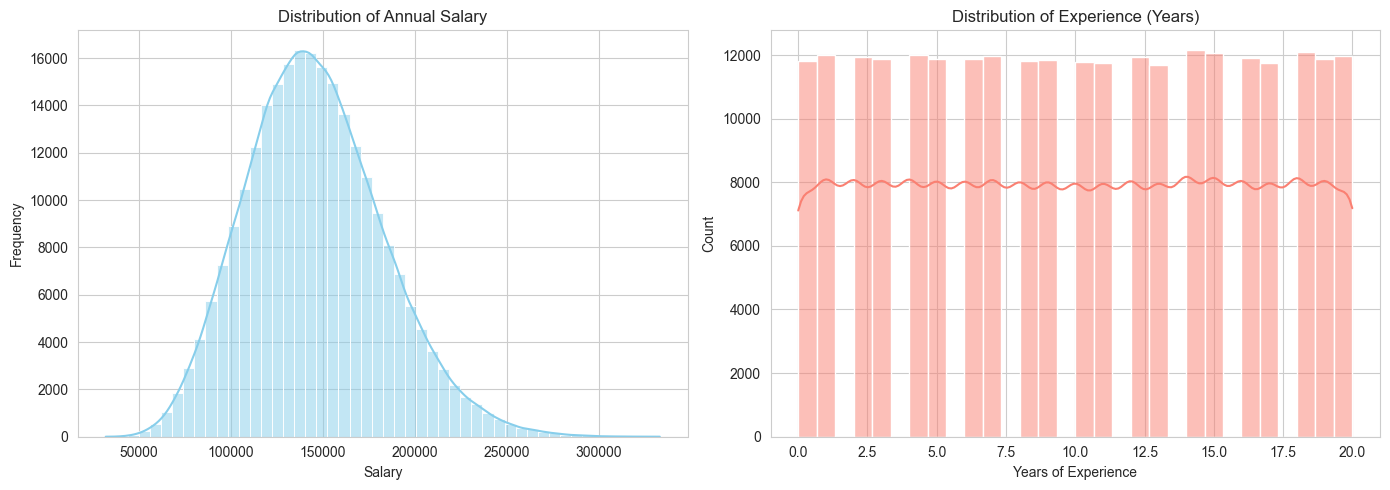

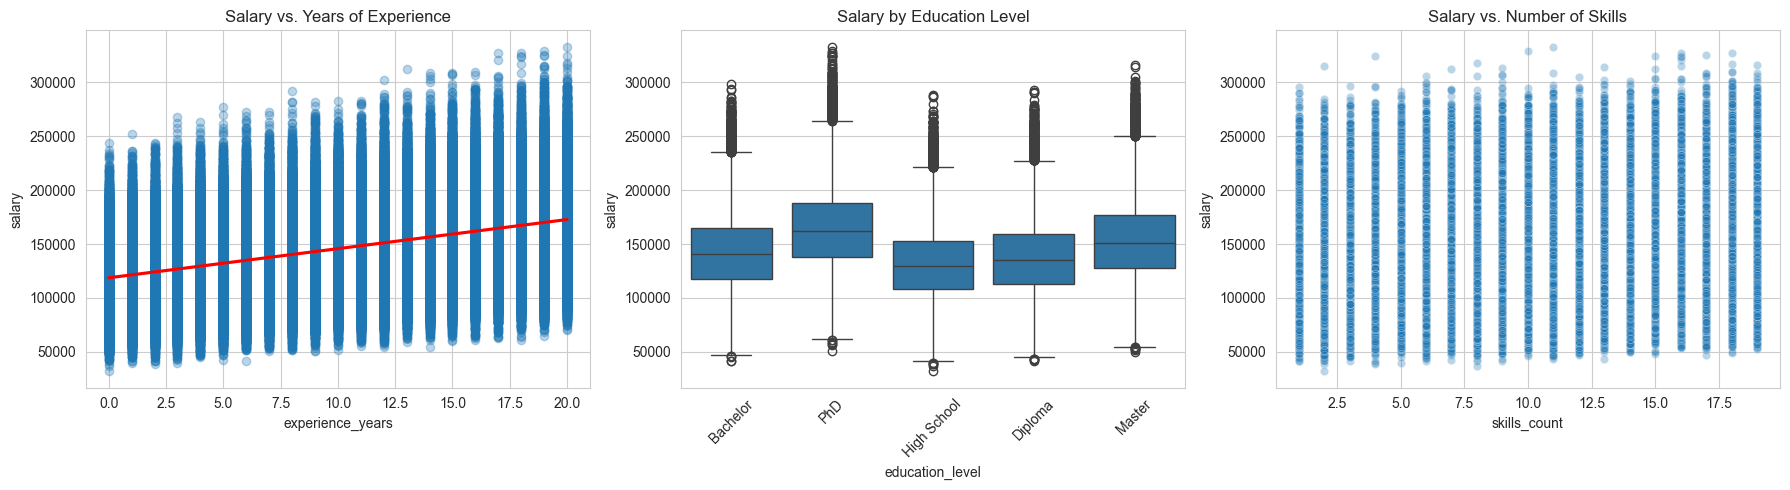

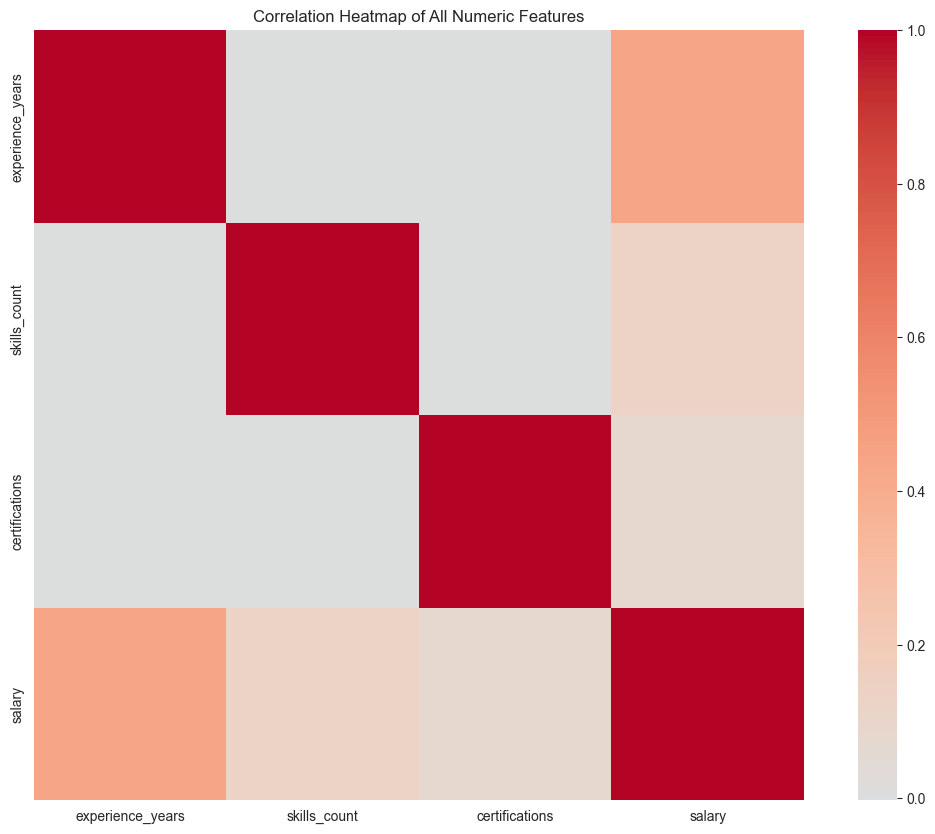

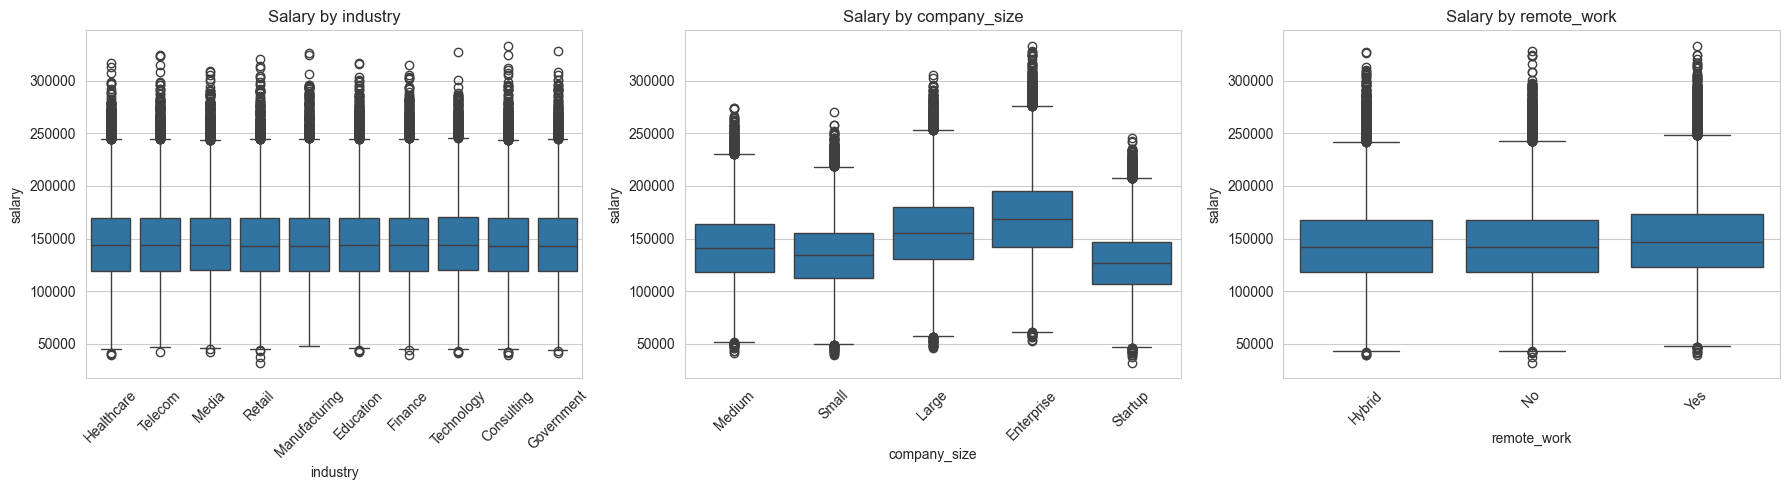

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Salary distribution – using df['salary']
sns.histplot(df['salary'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Annual Salary')
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Frequency')

# Experience years distribution
sns.histplot(df['experience_years'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Experience (Years)')
axes[1].set_xlabel('Years of Experience')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Salary vs. Experience (scatter + regression line)
sns.regplot(x='experience_years', y='salary', data=df, ax=axes[0], 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title('Salary vs. Years of Experience')

# Salary vs. Education Level (boxplot)
sns.boxplot(x='education_level', y='salary', data=df, ax=axes[1])
axes[1].set_title('Salary by Education Level')
axes[1].tick_params(axis='x', rotation=45)

# Salary vs. Skills Count (scatter)
sns.scatterplot(x='skills_count', y='salary', data=df, ax=axes[2], alpha=0.3)
axes[2].set_title('Salary vs. Number of Skills')

plt.tight_layout()
plt.show()

numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns
corr_matrix = df_encoded[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of All Numeric Features')
plt.show()

# Boxplots for salary across different categories
cat_features = ['industry', 'company_size', 'remote_work']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_features):
    sns.boxplot(x=col, y='salary', data=df, ax=axes[i])
    axes[i].set_title(f'Salary by {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()